<a href="https://colab.research.google.com/github/WakamYann237/Dogs-VS-Cats/blob/main/Dogs_and_Cats_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
train_dir = '/content/drive/My Drive/Datasets/Dogs vs Cats/train'
test_dir = '/content/drive/My Drive/Datasets/Dogs vs Cats/test_set'

In [ ]:
import os
list_dir = os.listdir(train_dir)
categories = []
for filename in list_dir:
  category = filename.split('.')[0]
  if category == 'dog':
    categories.append(1)
  else:
    categories.append(0)

In [ ]:
list_test_dir = os.listdir(test_dir)
categories_test = []
for filename in list_test_dir:
  category = filename.split('.')[0]
  if category == 'dog':
    categories_test.append(1)
  else:
    categories_test.append(0)

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'filename': list_dir,
    'category': categories
})
df_train = df.copy()
df_train

,filename,category
0,dog.3343.jpg,1
1,dog.3566.jpg,1
2,dog.3352.jpg,1
3,dog.3830.jpg,1
4,dog.3811.jpg,1
...,...,...
7995,cat.2247.jpg,0
7996,cat.1724.jpg,0
7997,cat.1909.jpg,0
7998,cat.222.jpg,0


In [ ]:
data_test = pd.DataFrame({
    'filename': list_test_dir,
    'category': categories_test
})
df_test = data_test.copy()
df_test

,filename,category
0,cat.4010.jpg,0
1,cat.4041.jpg,0
2,cat.4056.jpg,0
3,cat.4189.jpg,0
4,cat.4249.jpg,0
...,...,...
428,dog.4741.jpg,1
429,dog.4887.jpg,1
430,dog.4926.jpg,1
431,dog.4951.jpg,1


In [ ]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights= 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
for layer in conv_base.layers:
  if 'block5' in layer.name:
    layer.trainable = True
  else:
    layer.trainable = False

In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=60,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=0.2,
    fill_mode= 'nearest'
)

In [ ]:
df_train['category'] = df_train['category'].astype(str)
train_generator = train_datagen.flow_from_dataframe(
    df_train,
    train_dir,
    x_col= 'filename',
    y_col= 'category',
    target_size= (150,150),
    batch_size= 32,
    class_mode = 'binary'
)

Found 8000 validated image filenames belonging to 2 classes.


In [ ]:
df_test['category'] = df_test['category'].astype(str)
test_datagen = ImageDataGenerator(rescale= 1./255)
test_generator = test_datagen.flow_from_dataframe(
    df_test,
    test_dir,
    x_col= 'filename',
    y_col= 'category',
    target_size= (150,150),
    batch_size= 32,
    class_mode = 'binary'
)

Found 433 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(512, activation= 'relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation= 'sigmoid'))

In [ ]:
model.compile(
    optimizer= optimizers.RMSprop(learning_rate=2e-5),
    loss= 'binary_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
history= model.fit(
    train_generator,
    steps_per_epoch= 50,
    epochs= 30,
    validation_data= test_generator
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.6256 - loss: 0.6505 - val_accuracy: 0.7714 - val_loss: 0.4431
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 396ms/step - accuracy: 0.7812 - loss: 0.4642 - val_accuracy: 0.8822 - val_loss: 0.2528
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.8231 - loss: 0.3829 - val_accuracy: 0.7829 - val_loss: 0.4675
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 374ms/step - accuracy: 0.8119 - loss: 0.4052 - val_accuracy: 0.9145 - val_loss: 0.1930
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 362ms/step - accuracy: 0.8244 - loss: 0.3750 - val_accuracy: 0.9284 - val_loss: 0.1464
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 390ms/step - accuracy: 0.8537 - loss: 0.3282 - val_accuracy: 0.9284 - val_loss: 0.1469
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 412ms/step - accuracy: 0.8719 - loss: 0.2886 - val_accuracy: 0.9376 - val_loss: 0.1334
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 383ms/step - accuracy: 0.8706 - loss: 0.3021 - val_accura

In [ ]:
import matplotlib.pyplot as plt

# Courbes de validation
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 9))

# Courbe de l'exactitude
plt.subplot(2, 1, 1)
plt.plot(epochs, acc, 'bo', label='Exactitude entraînement')
plt.plot(epochs, val_acc, 'b', label='Exactitude validation')
plt.title("Exactitude de l'entraînement et de la validation")
plt.legend()

# Courbe de la perte
plt.subplot(2, 1, 2)
plt.plot(epochs, loss, 'bo', label='Perte entraînement')
plt.plot(epochs, val_loss, 'b', label='Perte validation')
plt.title("Perte de l'entraînement et de la validation")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# Évaluer le modèle sur l'ensemble de validation
loss, accuracy = model.evaluate(test_generator)
print(f"Validation Accuracy: {accuracy*100:.2f}%")  # Afficher l'exactitude de validation en pourcentage

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.9446 - loss: 0.1130
Validation Accuracy: 94.46%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


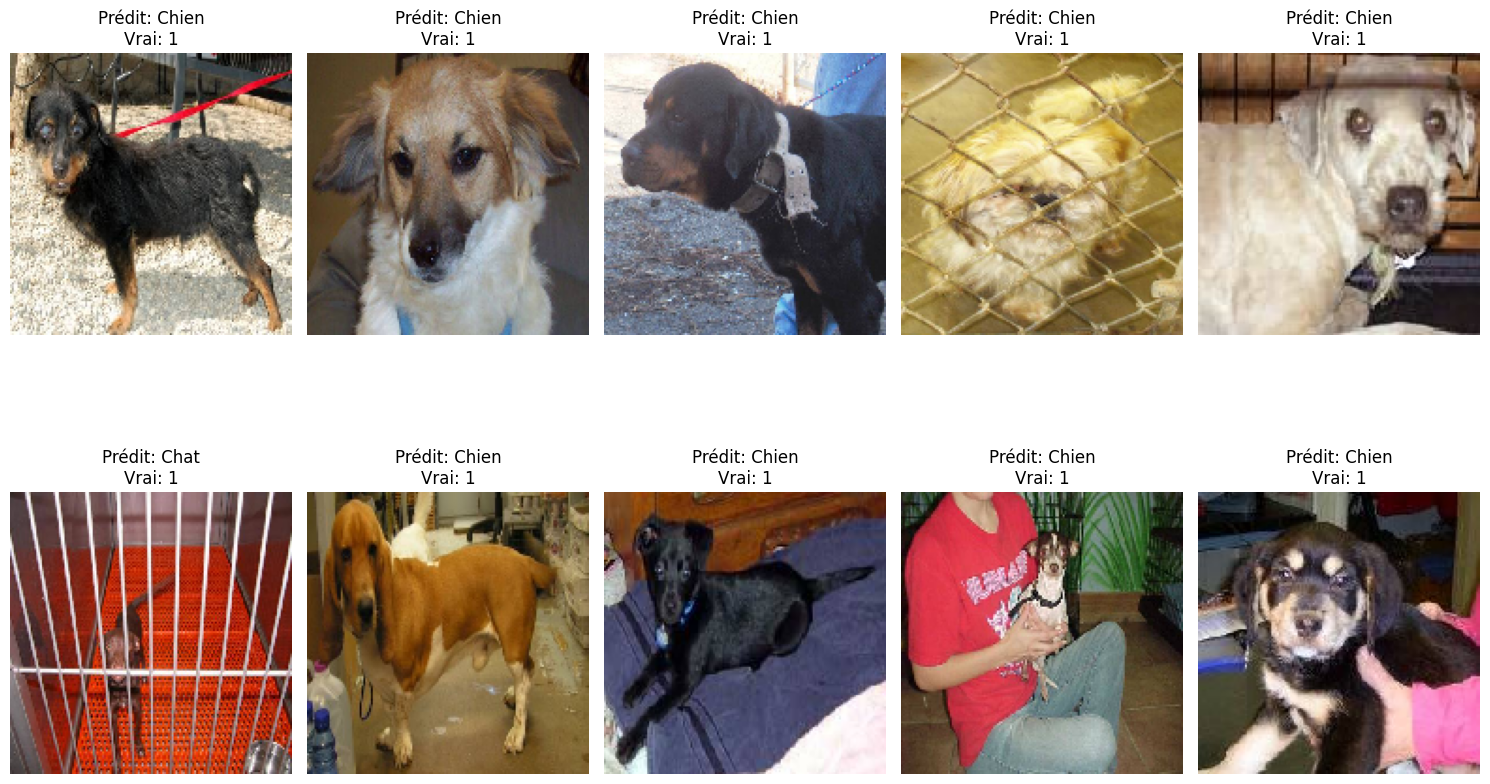

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Prédictions sur 10 images
sample_images = df_test.sample(10).reset_index(drop=True)  # Échantillonner 10 images de validation

plt.figure(figsize=(15, 10))
for i, row in sample_images.iterrows():
    img_path = os.path.join('/content/drive/My Drive/Datasets/Dogs vs Cats/test_set', row['filename'])
    img = image.load_img(img_path, target_size=(150, 150))
    img_tensor = image.img_to_array(img) / 255.0
    img_tensor = np.expand_dims(img_tensor, axis=0)

    prediction = model.predict(img_tensor)
    prediction_label = 'Chien' if prediction[0] > 0.5 else 'Chat'

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Prédit: {prediction_label}\nVrai: {row['category']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Sauvegarder le modèle entraîné
model.save('/content/drive/My Drive/cats_and_dogs_small_vgg16.h5')
